問題１  
シグモイド関数$p$が$dp/dz=p(1-p)$を満たすことを示してください。  
ただし式変形の過程は、このセルのようにMarkdownのセル上に記述してください。

Question 1.  
Show that the sigmoid function $p$ satisfies $dp/dz=p(1-p)$.  
The process of formula transformation should be written on a Markdown cell, as in this cell.

$$
p=\frac{1}{1+e^{-z}}
$$

**解答過程：**

与えられたシグモイド関数：
$$
p=\frac{1}{1+e^{-z}}
$$

zで微分すると：
$$
\begin{align}
\frac{dp}{dz} &= \frac{d}{dz}\left(\frac{1}{1+e^{-z}}\right) \notag \\
&= \frac{d}{dz}(1+e^{-z})^{-1} \notag \\
&= -1 \cdot (1+e^{-z})^{-2} \cdot \frac{d}{dz}(1+e^{-z}) \notag \\
&= -1 \cdot (1+e^{-z})^{-2} \cdot (-e^{-z}) \notag \\
&= \frac{e^{-z}}{(1+e^{-z})^2} \notag \\
&= \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} \notag \\
&= p \cdot \frac{e^{-z}}{1+e^{-z}} \notag
\end{align}
$$

ここで、以下のことに注意する：
$$
\frac{e^{-z}}{1+e^{-z}} = \frac{1+e^{-z}-1}{1+e^{-z}} = 1 - \frac{1}{1+e^{-z}} = 1-p
$$

したがって：
$$
\frac{dp}{dz} = p(1-p)
$$

**証明完了。**

問題２  
wineのデータセットで下の訓練データ（X_train, y_train）を用いてk近傍法で分類することを考えます。
このとき横軸を近傍点の数（n_neighbors, 1から100まで）、縦軸を訓練データ、及びテストデータの正解率（score）とした図を作成してください。  
学習の前にデータの標準化（平均ゼロ、標準偏差１）をする必要があることにご注意ください。

Question 2  
Consider classification by k-nearest neighbor method (kNN) using the training data below (X_train, y_train) on the wine dataset.
At this time, please create a diagram with the number of neighbor points (n_neighbors, from 1 to 100) on the horizontal axis and the percentage of correct answers (score) for the training and test data on the vertical axis.  
Please note that the data must be standardized (mean zero, standard deviation one) prior to training.

In [6]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

# wine
wine = datasets.load_wine() # wineのデータを辞書型で取得
X, y = wine['data'], wine['target'] # 特徴量とターゲットを取得

# 訓練データとテスト(検証)データに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

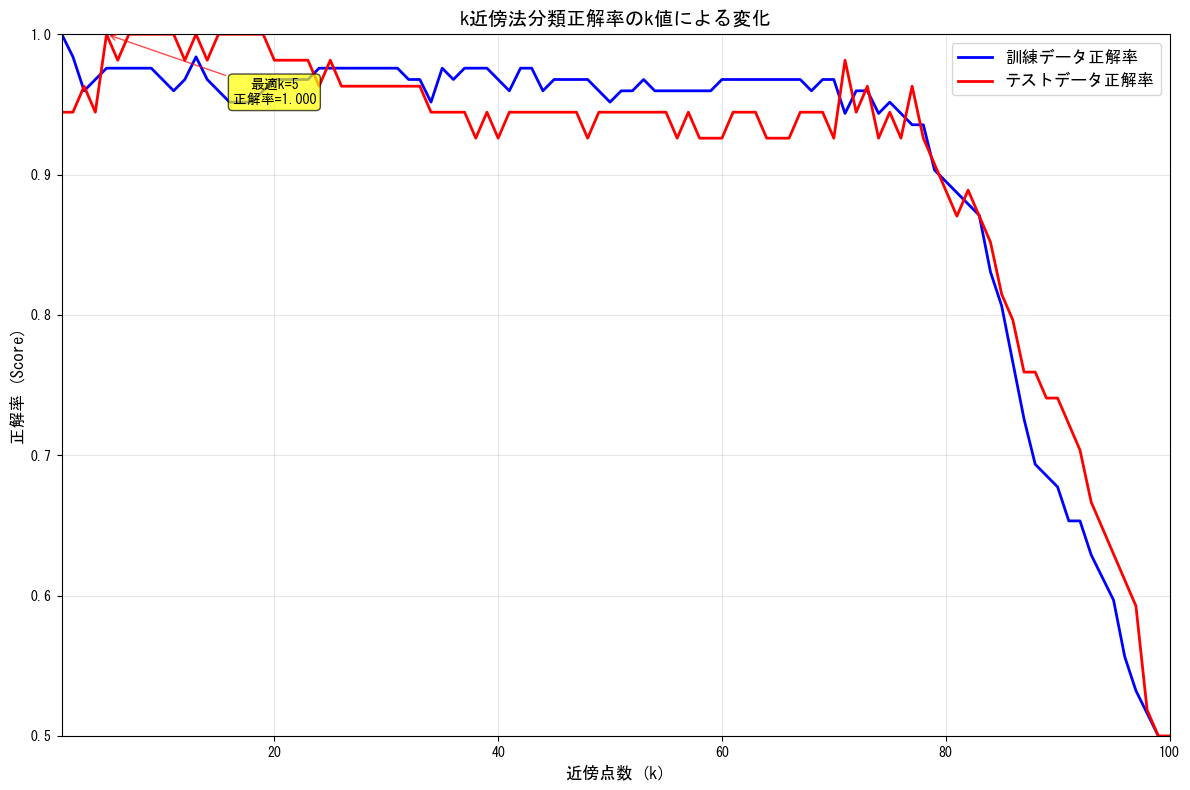

データセット情報:
- 訓練サンプル数: 124
- テストサンプル数: 54
- 特徴量次元: 13
- クラス数: 3

最適結果:
- テストデータ最適k値: 5
- テストデータ最高正解率: 1.0000
- 対応する訓練データ正解率: 0.9758

極端ケースの比較:
- k=1時: 訓練正解率=1.0000, テスト正解率=0.9444
- k=100時: 訓練正解率=0.4677, テスト正解率=0.5000


In [7]:
# 必要なライブラリをインポート
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings

# フォント警告を非表示にする
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing from font.*')

# 日本語フォントの設定（利用可能なフォントを試す）
import matplotlib.font_manager as fm

# 日本語対応フォントを探す
japanese_fonts = ['MS Gothic', 'Yu Gothic', 'Meiryo', 'Hiragino Sans', 'IPAexGothic', 'NotoSansCJK']
font_found = False

for font in japanese_fonts:
    try:
        plt.rcParams['font.family'] = font
        font_found = True
        break
    except:
        continue

# 日本語フォントが見つからない場合は英語で表示
if not font_found:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    use_english = True
else:
    use_english = False

plt.rcParams['axes.unicode_minus'] = False

# データの標準化処理
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 訓練データの標準化
X_test_scaled = scaler.transform(X_test)        # テストデータは訓練データの標準化パラメータを使用

# 結果を保存するリストを初期化
k_values = range(1, 101)  # k値を1から100まで
train_scores = []         # 訓練データの正解率
test_scores = []          # テストデータの正解率

# 異なるk値でテストを実行
for k in k_values:
    # k近傍分類器を作成
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # モデルを訓練
    knn.fit(X_train_scaled, y_train)
    
    # 訓練データの正解率を計算
    train_pred = knn.predict(X_train_scaled)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_scores.append(train_accuracy)
    
    # テストデータの正解率を計算
    test_pred = knn.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_scores.append(test_accuracy)

# 結果のグラフを作成
plt.figure(figsize=(12, 8))

# 最適なk値を事前に計算
best_test_k = k_values[np.argmax(test_scores)]
best_test_score = max(test_scores)

# 言語設定に応じてラベルを設定
if use_english:
    train_label = 'Training Data Accuracy'
    test_label = 'Test Data Accuracy'
    xlabel = 'Number of Neighbors (k)'
    ylabel = 'Accuracy Score'
    title = 'k-NN Classification Accuracy vs k Value'
    annotation_text = f'Best k={best_test_k}\nAccuracy={best_test_score:.3f}'
else:
    train_label = '訓練データ正解率'
    test_label = 'テストデータ正解率'
    xlabel = '近傍点数 (k)'
    ylabel = '正解率 (Score)'
    title = 'k近傍法分類正解率のk値による変化'
    annotation_text = f'最適k={best_test_k}\n正解率={best_test_score:.3f}'

plt.plot(k_values, train_scores, 'b-', label=train_label, linewidth=2)
plt.plot(k_values, test_scores, 'r-', label=test_label, linewidth=2)

# グラフの装飾を追加
plt.xlabel(xlabel, fontsize=12)
plt.ylabel(ylabel, fontsize=12)
plt.title(title, fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(1, 100)
plt.ylim(0.5, 1.0)

# 最適なk値の注釈を追加
plt.annotate(annotation_text, 
             xy=(best_test_k, best_test_score), 
             xytext=(best_test_k+15, best_test_score-0.05),
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
             fontsize=10, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

# 統計情報を出力
print(f"データセット情報:")
print(f"- 訓練サンプル数: {X_train.shape[0]}")
print(f"- テストサンプル数: {X_test.shape[0]}")
print(f"- 特徴量次元: {X_train.shape[1]}")
print(f"- クラス数: {len(np.unique(y))}")
print(f"\n最適結果:")
print(f"- テストデータ最適k値: {best_test_k}")
print(f"- テストデータ最高正解率: {best_test_score:.4f}")
print(f"- 対応する訓練データ正解率: {train_scores[best_test_k-1]:.4f}")

# k=1とk=100時の正解率比較を表示
print(f"\n極端ケースの比較:")
print(f"- k=1時: 訓練正解率={train_scores[0]:.4f}, テスト正解率={test_scores[0]:.4f}")
print(f"- k=100時: 訓練正解率={train_scores[-1]:.4f}, テスト正解率={test_scores[-1]:.4f}")
